In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [19]:
columns = [
    "unit_number", "time_in_cycles", "setting_1", "setting_2", "TRA",
    "T2", "T24", "T30", "T50", "P2", "P15", "P30", "Nf", "Nc", "epr",
    "Ps30", "phi", "NRf", "NRc", "BPR", "farB", "htBleed", "Nf_dmd",
    "PCNfR_dmd", "W31", "W32"
]


In [20]:
train_raw = pd.read_csv("CMaps/train_FD001.txt", sep=r"\s+", header=None, names=columns)
test_raw = pd.read_csv("CMaps/test_FD001.txt", sep=r"\s+", header=None, names=columns)
rul_raw = pd.read_csv("CMaps/RUL_FD001.txt", sep=r"\s+", header=None).values.flatten()

In [21]:
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("RUL shape:", rul_raw.shape)


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100,)


In [22]:
print("--- Data Types ---")
print(train_raw.dtypes)
print("\n--- Column Names ---")
print(train_raw.columns.tolist())

--- Data Types ---
unit_number         int64
time_in_cycles      int64
setting_1         float64
setting_2         float64
TRA               float64
T2                float64
T24               float64
T30               float64
T50               float64
P2                float64
P15               float64
P30               float64
Nf                float64
Nc                float64
epr               float64
Ps30              float64
phi               float64
NRf               float64
NRc               float64
BPR               float64
farB              float64
htBleed             int64
Nf_dmd              int64
PCNfR_dmd         float64
W31               float64
W32               float64
dtype: object

--- Column Names ---
['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'TRA', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']


In [23]:
print("--- Train Head ---")
print(train_raw.head())
print("\n--- Train Tail ---")
print(train_raw.tail())

--- Train Head ---
   unit_number  time_in_cycles  setting_1  setting_2    TRA      T2     T24  \
0            1               1    -0.0007    -0.0004  100.0  518.67  641.82   
1            1               2     0.0019    -0.0003  100.0  518.67  642.15   
2            1               3    -0.0043     0.0003  100.0  518.67  642.35   
3            1               4     0.0007     0.0000  100.0  518.67  642.35   
4            1               5    -0.0019    -0.0002  100.0  518.67  642.37   

       T30      T50     P2  ...     phi      NRf      NRc     BPR  farB  \
0  1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   
1  1591.82  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03   
2  1587.99  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03   
3  1582.79  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03   
4  1582.85  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03   

   htBleed  Nf_dmd  PCNfR_dmd    W31      W32  
0      

In [24]:
print("--- Train Summary Statistics ---")
print(train_raw.describe().T)

--- Train Summary Statistics ---
                  count         mean           std        min        25%  \
unit_number     20631.0    51.506568  2.922763e+01     1.0000    26.0000   
time_in_cycles  20631.0   108.807862  6.888099e+01     1.0000    52.0000   
setting_1       20631.0    -0.000009  2.187313e-03    -0.0087    -0.0015   
setting_2       20631.0     0.000002  2.930621e-04    -0.0006    -0.0002   
TRA             20631.0   100.000000  0.000000e+00   100.0000   100.0000   
T2              20631.0   518.670000  6.537152e-11   518.6700   518.6700   
T24             20631.0   642.680934  5.000533e-01   641.2100   642.3250   
T30             20631.0  1590.523119  6.131150e+00  1571.0400  1586.2600   
T50             20631.0  1408.933782  9.000605e+00  1382.2500  1402.3600   
P2              20631.0    14.620000  3.394700e-12    14.6200    14.6200   
P15             20631.0    21.609803  1.388985e-03    21.6000    21.6100   
P30             20631.0   553.367711  8.850923e-01   54

In [25]:
eol_train = train_raw.groupby('unit_number')['time_in_cycles'].transform('max')
train_raw['RUL'] = eol_train - train_raw['time_in_cycles']
train_raw['LR'] = train_raw['time_in_cycles'] / eol_train

In [ ]:

def get_label(lr):
    if lr <= 0.6: return 0
    elif lr <= 0.8: return 1
    else: return 2

train_raw['labels'] = train_raw['LR'].apply(get_label)

In [ ]:

max_cycles_test = test_raw.groupby('unit_number')['time_in_cycles'].transform('max')
rul_map = {eng: rul_raw[eng - 1] for eng in test_raw['unit_number'].unique()}
test_raw['EOL'] = max_cycles_test + test_raw['unit_number'].map(rul_map)
test_raw['RUL'] = test_raw['EOL'] - test_raw['time_in_cycles']
test_raw['LR'] = test_raw['time_in_cycles'] / test_raw['EOL']
test_raw['labels'] = test_raw['LR'].apply(get_label)

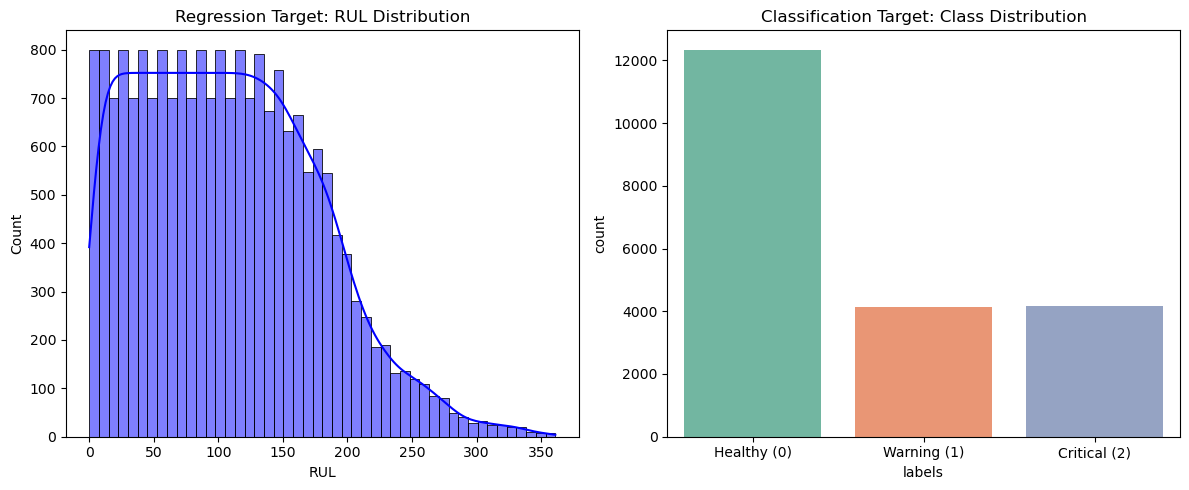

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_raw['RUL'], kde=True, color='blue')
plt.title('Regression Target: RUL Distribution')




plt.subplot(1, 2, 2)
sns.countplot(x='labels', data=train_raw, palette='Set2')
plt.title('Classification Target: Class Distribution')
plt.xticks(ticks=[0, 1, 2], labels=['Healthy (0)', 'Warning (1)', 'Critical (2)'])
plt.tight_layout()
plt.show()

In [29]:
print("--- Missing Values in Train ---")
missing_count = train_raw.isnull().sum()
missing_percent = (missing_count / len(train_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])
print("No missing values found.")

--- Missing Values in Train ---
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []
No missing values found.


In [30]:
dup_count = train_raw.duplicated().sum()
print(f"Number of duplicate rows in training data: {dup_count}")

Number of duplicate rows in training data: 0


In [31]:
# 1.8 Outlier detection using IQR on a sample sensor (T24)
q1 = train_raw['T24'].quantile(0.25)
q3 = train_raw['T24'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = train_raw[(train_raw['T24'] < lower_bound) | (train_raw['T24'] > upper_bound)]
print(f"Sensor T24 Outliers Count: {len(outliers)} out of {len(train_raw)} rows")

Sensor T24 Outliers Count: 128 out of 20631 rows


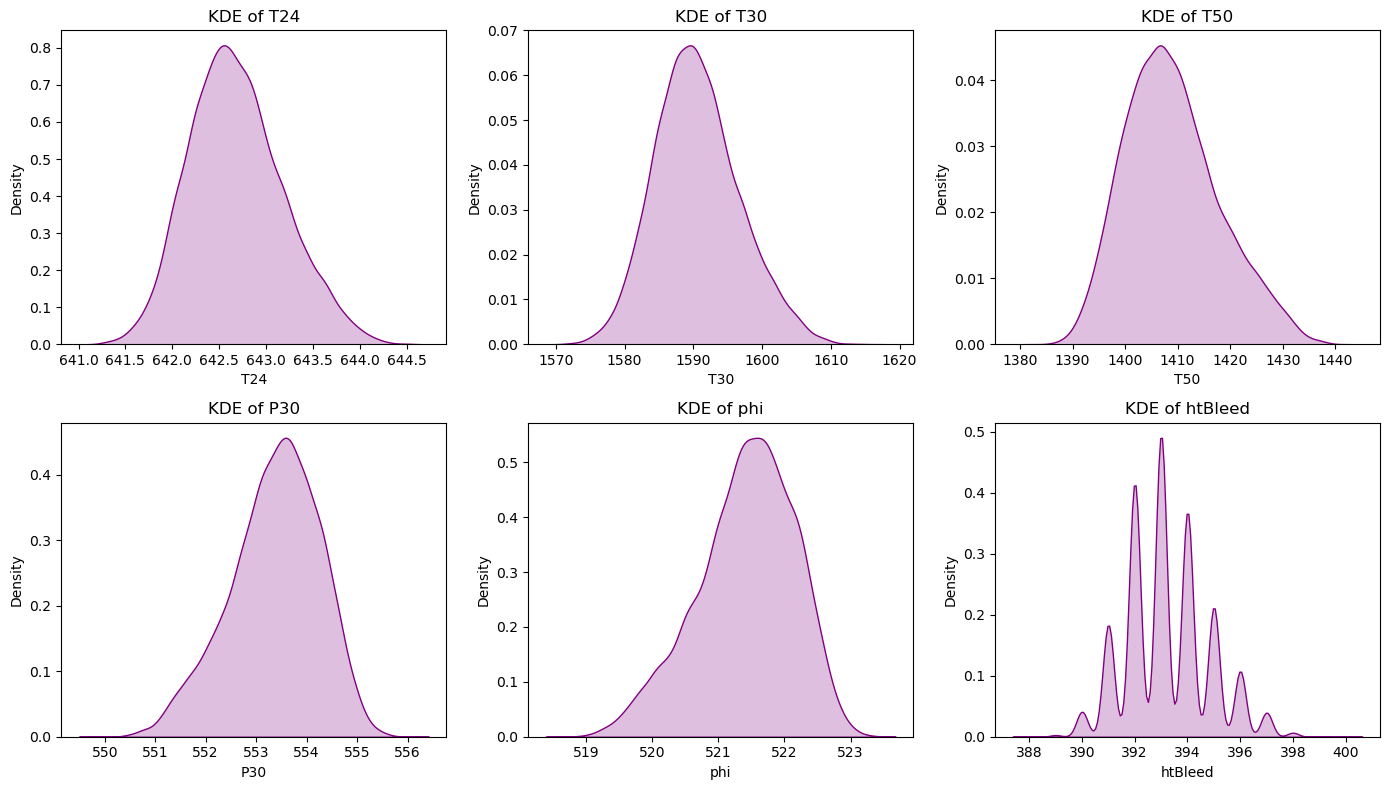

In [32]:
active_sensors = ['T24', 'T30', 'T50', 'P30', 'phi', 'htBleed']
plt.figure(figsize=(14, 8))
for i, sensor in enumerate(active_sensors, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(train_raw[sensor], fill=True, color='purple')
    plt.title(f'KDE of {sensor}')
plt.tight_layout()
plt.show()

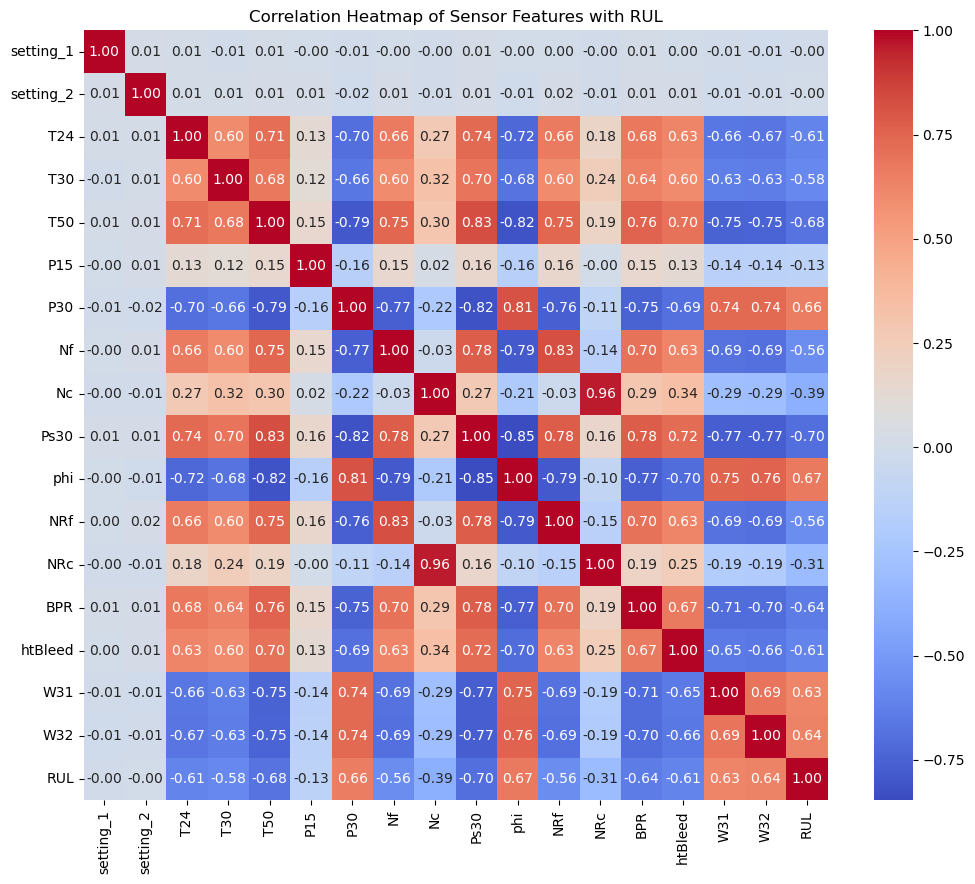

In [33]:
sensor_cols = ['setting_1', 'setting_2', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
corr_matrix = train_raw[sensor_cols + ['RUL']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Sensor Features with RUL")
plt.show()

In [ ]:

train_cleaned = train_raw.drop_duplicates()
print(f"Cleaned train shape: {train_cleaned.shape}")

constant_cols = [col for col in train_cleaned.columns if train_cleaned[col].std() < 0.01]
print("Dropping constant/flatline features:", constant_cols)

train_cleaned = train_cleaned.drop(columns=constant_cols)
test_cleaned = test_raw.drop(columns=constant_cols, errors='ignore')

Cleaned train shape: (20631, 29)
Dropping constant/flatline features: ['setting_1', 'setting_2', 'TRA', 'T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']


In [ ]:

train_cleaned['RUL'] = train_cleaned['RUL'].clip(upper=125)

test_cleaned['RUL'] = test_cleaned['RUL'].clip(upper=125)

In [ ]:
features_to_drop = ['unit_number', 'RUL', 'LR', 'labels', 'EOL']

X_train_raw = train_cleaned.drop(columns=[col for col in features_to_drop if col in train_cleaned.columns])
y_train_class = train_cleaned['labels']
y_train_reg = train_cleaned['RUL']

X_test_raw = test_cleaned.drop(columns=[col for col in features_to_drop if col in test_cleaned.columns])
y_test_class = test_cleaned['labels']
y_test_reg = test_cleaned['RUL']

print("Features list:", X_train_raw.columns.tolist())

Features list: ['time_in_cycles', 'T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print("Scaled features head sample:")
print(X_train_scaled.head())


Scaled features head sample:
   time_in_cycles       T24       T30       T50       P30        Nf        Nc  \
0       -1.565170 -1.721725 -0.134255 -0.925936  1.121141 -0.516338 -0.862813   
1       -1.550652 -1.061780  0.211528 -0.643726  0.431930 -0.798093 -0.958818   
2       -1.536134 -0.661813 -0.413166 -0.525953  1.008155 -0.234584 -0.557139   
3       -1.521616 -0.661813 -1.261314 -0.784831  1.222827  0.188048 -0.713826   
4       -1.507098 -0.621816 -1.251528 -0.301518  0.714393 -0.516338 -0.457059   

       Ps30       phi       NRf       NRc       BPR   htBleed       W31  \
0 -0.266467  0.334262 -1.058890 -0.269071 -0.603816 -0.781710  1.348493   
1 -0.191583  1.174899 -0.363646 -0.642845 -0.275852 -0.781710  1.016528   
2 -1.015303  1.364721 -0.919841 -0.551629 -0.649144 -2.073094  0.739891   
3 -1.539489  1.961302 -0.224597 -0.520176 -1.971665 -0.781710  0.352598   
4 -0.977861  1.052871 -0.780793 -0.521748 -0.339845 -0.136018  0.463253   

        W32  
0  1.194427  
1  1.

In [ ]:
sensor_active = ['T24', 'T30', 'T50', 'P30', 'phi', 'htBleed', 'W31', 'W32']

train_cleaned_eng = train_cleaned.copy()

test_cleaned_eng = test_cleaned.copy()

for col in sensor_active:
    train_cleaned_eng[f"{col}_rolling_mean"] = train_cleaned_eng.groupby("unit_number")[col].rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
    test_cleaned_eng[f"{col}_rolling_mean"] = test_cleaned_eng.groupby("unit_number")[col].rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)


X_tr_eng = train_cleaned_eng.drop(columns=[col for col in features_to_drop if col in train_cleaned_eng.columns])
X_te_eng = test_cleaned_eng.drop(columns=[col for col in features_to_drop if col in test_cleaned_eng.columns])


scaler_eng = StandardScaler()
X_tr_eng_scaled = pd.DataFrame(scaler_eng.fit_transform(X_tr_eng), columns=X_tr_eng.columns)
X_te_eng_scaled = pd.DataFrame(scaler_eng.transform(X_te_eng), columns=X_te_eng.columns)

print("Engineered features list:", X_tr_eng_scaled.columns.tolist())


Engineered features list: ['time_in_cycles', 'T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32', 'T24_rolling_mean', 'T30_rolling_mean', 'T50_rolling_mean', 'P30_rolling_mean', 'phi_rolling_mean', 'htBleed_rolling_mean', 'W31_rolling_mean', 'W32_rolling_mean']


In [ ]:

corr_with_reg = X_tr_eng_scaled.corrwith(y_train_reg).abs()
selected_features = corr_with_reg[corr_with_reg > 0.1].index.tolist()

print(f"Selected {len(selected_features)} features with target correlation > 0.1:")
print(selected_features)

X_train_final = X_tr_eng_scaled[selected_features]
X_test_final = X_te_eng_scaled[selected_features]


Selected 23 features with target correlation > 0.1:
['time_in_cycles', 'T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32', 'T24_rolling_mean', 'T30_rolling_mean', 'T50_rolling_mean', 'P30_rolling_mean', 'phi_rolling_mean', 'htBleed_rolling_mean', 'W31_rolling_mean', 'W32_rolling_mean']


In [40]:
# 4.1 & 4.2 Select baseline models & Fit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

print("Fitting baseline models...")

# Baseline Classifier (Random Forest)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_final, y_train_class)

Fitting baseline models...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [51]:
# Baseline Regressor (Random Forest)
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train_final, y_train_reg)



RandomForestRegressor(n_jobs=-1, random_state=42)

In [42]:
# 5.1 & 5.2 Generate predictions and evaluate Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_class_train = rf_classifier.predict(X_train_final)
y_pred_class_test = rf_classifier.predict(X_test_final)

print("=== CLASSIFICATION EVALUATION ===")
print("Train Accuracy:", accuracy_score(y_train_class, y_pred_class_train))
print("Test Accuracy :", accuracy_score(y_test_class, y_pred_class_test))
print("\nTest Classification Report:")
print(classification_report(y_test_class, y_pred_class_test, target_names=['Healthy (0)', 'Warning (1)', 'Critical (2)']))


=== CLASSIFICATION EVALUATION ===
Train Accuracy: 1.0
Test Accuracy : 0.9093616371411118

Test Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.96      0.95      0.96     10941
 Warning (1)       0.62      0.71      0.66      1609
Critical (2)       0.79      0.68      0.73       546

    accuracy                           0.91     13096
   macro avg       0.79      0.78      0.78     13096
weighted avg       0.91      0.91      0.91     13096



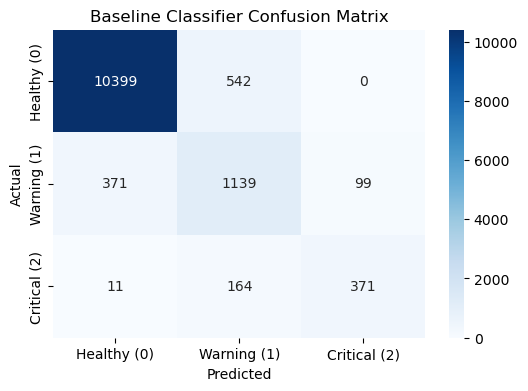

In [43]:
# 5.4 Plot Confusion Matrix for Classification
cm = confusion_matrix(y_test_class, y_pred_class_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Warning (1)', 'Critical (2)'],
            yticklabels=['Healthy (0)', 'Warning (1)', 'Critical (2)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline Classifier Confusion Matrix')
plt.show()


In [44]:
# 5.1 & 5.2 Evaluate Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_reg_train = rf_regressor.predict(X_train_final)
y_pred_reg_test = rf_regressor.predict(X_test_final)

print("=== REGRESSION EVALUATION ===")
print(f"Train MAE:  {mean_absolute_error(y_train_reg, y_pred_reg_train):.4f}  | Test MAE:  {mean_absolute_error(y_test_reg, y_pred_reg_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_reg_train)):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_test)):.4f}")
print(f"Train R2:   {r2_score(y_train_reg, y_pred_reg_train):.4f}  | Test R2:   {r2_score(y_test_reg, y_pred_reg_test):.4f}")


=== REGRESSION EVALUATION ===
Train MAE:  3.3899  | Test MAE:  10.0874
Train RMSE: 5.1682 | Test RMSE: 15.9355
Train R2:   0.9846  | Test R2:   0.6661


In [ ]:
from sklearn.model_selection import cross_val_score


cv_class_scores = cross_val_score(rf_classifier, X_train_final, y_train_class, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Classifier CV Accuracy: {cv_class_scores.mean():.4f} +/- {cv_class_scores.std():.4f}")


cv_reg_scores = cross_val_score(rf_regressor, X_train_final, y_train_reg, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"Regressor CV RMSE: {-cv_reg_scores.mean():.4f} +/- {cv_reg_scores.std():.4f}")


Classifier CV Accuracy: 0.8763 +/- 0.0245
Regressor CV RMSE: 16.6097 +/- 2.2453


In [ ]:
from sklearn.model_selection import RandomizedSearchCV


param_dist_class = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

print("Running Randomized Search Tuning for Classifier (this might take a few seconds)...")
random_search_class = RandomizedSearchCV(RandomForestClassifier(random_state=42), 
                                         param_distributions=param_dist_class, 
                                         n_iter=5, cv=3, scoring='accuracy', 
                                         random_state=42, n_jobs=-1)
random_search_class.fit(X_train_final, y_train_class)

best_classifier = random_search_class.best_estimator_
print("Best Classifier Parameters:", random_search_class.best_params_)


Running Randomized Search Tuning for Classifier (this might take a few seconds)...
Best Classifier Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 10}


In [47]:
# Define search grid for Regressor
param_dist_reg = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

print("Running Randomized Search Tuning for Regressor...")
random_search_reg = RandomizedSearchCV(RandomForestRegressor(random_state=42), 
                                       param_distributions=param_dist_reg, 
                                       n_iter=5, cv=3, scoring='neg_root_mean_squared_error', 
                                       random_state=42, n_jobs=-1)
random_search_reg.fit(X_train_final, y_train_reg)

best_regressor = random_search_reg.best_estimator_
print("Best Regressor Parameters:", random_search_reg.best_params_)


Running Randomized Search Tuning for Regressor...
Best Regressor Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 10}


In [ ]:

y_final_pred_class = best_classifier.predict(X_test_final)
y_final_pred_reg = best_regressor.predict(X_test_final)

print("=== FINAL TUNED CLASSIFIER ON TEST SET ===")
print("Accuracy Score:", accuracy_score(y_test_class, y_final_pred_class))
print("F1-Score (Macro):", f1_score(y_test_class, y_final_pred_class, average='macro'))

print("\n=== FINAL TUNED REGRESSOR ON TEST SET ===")
print("MAE  Score:", mean_absolute_error(y_test_reg, y_final_pred_reg))
print("RMSE Score:", np.sqrt(mean_squared_error(y_test_reg, y_final_pred_reg)))
print("R2   Score:", r2_score(y_test_reg, y_final_pred_reg))


=== FINAL TUNED CLASSIFIER ON TEST SET ===
Accuracy Score: 0.911805131337813
F1-Score (Macro): 0.7826859666478759

=== FINAL TUNED REGRESSOR ON TEST SET ===
MAE  Score: 9.877012437530308
RMSE Score: 15.594908817675003
R2   Score: 0.6802561508227127


In [49]:
# 9.1 & 9.2 Analyze Classification mistakes
error_df = pd.DataFrame({'Actual': y_test_class, 'Predicted': y_final_pred_class})
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

print(f"Total misclassified instances: {len(misclassified)} out of {len(y_test_class)}")
print("\nDistribution of Misclassified Classes (Actual):")
print(misclassified['Actual'].value_counts())
print("\nDistribution of Misclassified Classes (Predicted):")
print(misclassified['Predicted'].value_counts())


Total misclassified instances: 1155 out of 13096

Distribution of Misclassified Classes (Actual):
Actual
0    487
1    487
2    181
Name: count, dtype: int64

Distribution of Misclassified Classes (Predicted):
Predicted
1    660
0    402
2     93
Name: count, dtype: int64


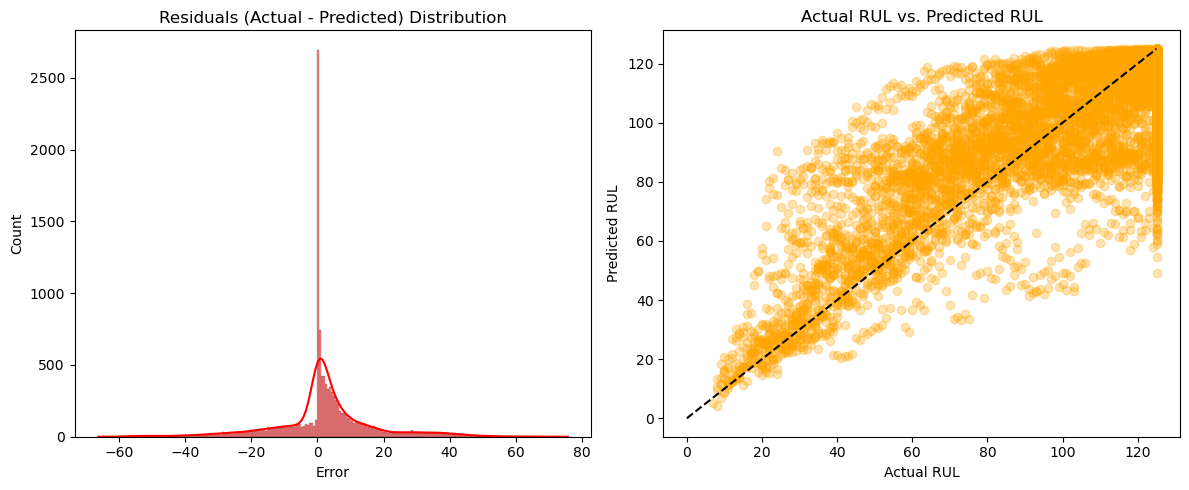

In [50]:
# 9.3 Analyze Regression Errors (Residuals)
residuals = y_test_reg - y_final_pred_reg

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='red')
plt.title('Residuals (Actual - Predicted) Distribution')
plt.xlabel('Error')

plt.subplot(1, 2, 2)
plt.scatter(y_test_reg, y_final_pred_reg, alpha=0.3, color='orange')
plt.plot([0, 125], [0, 125], '--k')
plt.title('Actual RUL vs. Predicted RUL')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.tight_layout()
plt.show()
